# Retriving monthly filings volume at the EPO - forecasting

Welcome to the first notebook on **filings forecasting**, where we load and process the data that will be used in the next notebook to train a forecasting model to predict the future number of filings. It is worth to remind that these two notebooks require a basic knowledge on statistics and forecasting models. Despite being advanced, this showcase on applications projection is far from being a complete and comprehensive study.

This notebook is a companion to an article published in the EPO's [Patent Knowledge News](https://www.epo.org/en/searching-for-patents/helpful-resources/patent-knowledge-news) where we explore time series forecasting for patent filing activity. By importing external libraries and implementing open-source models, we leverage historic filing and economic data to make mathematical predictions of the filing activity. This is the first of two notebooks associated with the article.

This first notebook, DataLoading, focuses on data preparation and preliminary analysis. It loads different datasets such as PATSTAT and the Geographic Dataset, which groups applicants by region (USA, South Korea, EPO members, China, and Japan). The patent and geographic data are combined with economic data as an exogenous factor for the modelling. We leverage TIP’s data visualisation features to highlight trends, seasonality, and structural patterns, including GDP's correlation with filing volumes.

## Prerrequisites

This notebook has been written for an audience already familiar with TIP. For users completely new to the platform, we recommend to follow the [TIP basic course](https://e-courses.epo.org/enrol/index.php?id=416) before reading this analysis.

## Disclaimer

This notebook is published as a showcase of the capabilities of TIP as a data processing environment. It is not intended to derive any statistical conclusion other than the presentation of the retrieved data. The EPO is not expressing any opinion extrapolated from the analysis.

## Unique time series

In this section we extract the monthly filings numbers without caring of the country or area of the applicant.

### PATSTAT data

We start initialising the PATSTAT client and accessing ORM. Then we import PATSTAT table TLS201 to retrieve the data we need, i.e. the number of applications filed at the EPO in a specific time window. We also import the modules needed to accomplish these first operations.

In [1]:
from epo.tipdata.patstat import PatstatClient

# Initialise the PATSTAT client
patstat = PatstatClient(env='PROD')

# Access ORM
db = patstat.orm()

# Importing the as models
from epo.tipdata.patstat.database.models import TLS201_APPLN
from sqlalchemy import func
import matplotlib.pyplot as plt
from datetime import datetime

We are ready to count the number of applications having 'EP' as `appln_auth` filtering the ones filed between 2012 and 2021. We extract the month from the filing date and we group by filing year and month. The ordering is done first by filing year and then by filing month. We then save the data in year-month format.

In [2]:
import os

home = os.environ["HOME"]
csv_path = f"{home}/unique_ts.csv"

epo_ts = db.query(
    TLS201_APPLN.appln_filing_year,
    func.extract('month', TLS201_APPLN.appln_filing_date).label('Month'),
    func.count(TLS201_APPLN.appln_id).label('Number of filings')
).filter(
    TLS201_APPLN.appln_auth == 'EP',
    TLS201_APPLN.appln_filing_year > 2011,
    TLS201_APPLN.appln_filing_year < 2022
).group_by(
    TLS201_APPLN.appln_filing_year,
    func.extract('month', TLS201_APPLN.appln_filing_date)
).order_by(
    TLS201_APPLN.appln_filing_year,
    'Month'
)

unique_ts = patstat.df(epo_ts)
# Join year and month in the same column
unique_ts['year_month'] = [f"{year}-{month}" for year, month in zip(unique_ts['appln_filing_year'], unique_ts['Month'])]
# Delete the year and month columns from the dataframe
unique_ts = unique_ts.drop(['appln_filing_year', 'Month'], axis=1)
# Save the dataframe in a csv file
unique_ts.to_csv(csv_path, index=False)
unique_ts

,Number of filings,year_month
0,9922,2012-1
1,11562,2012-2
2,14409,2012-3
3,11441,2012-4
4,12754,2012-5
...,...,...
115,13707,2021-8
116,15769,2021-9
117,14728,2021-10
118,15432,2021-11


The first thing to do to have an outlook on the data at hand is to plot the time series in order to spot any evident pattern like trend and seasonality.

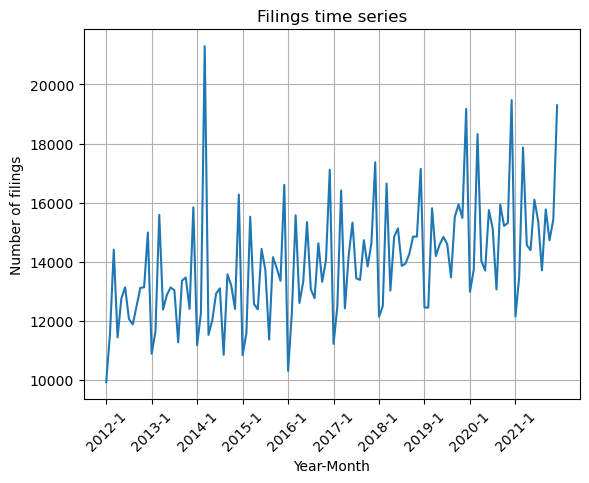

In [3]:
fig, ax = plt.subplots()

# Define the amounts to be displayed retriving them from the dataframe created in the previous box
year_month = unique_ts['year_month']
filings = unique_ts['Number of filings']
dates_subset = year_month[::12]

ax.plot(year_month, filings)

plt.xticks(dates_subset, rotation=45)

# Set axes labels and title of the plot
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of filings')
ax.set_title('Filings time series')

plt.grid(True)

plt.show()

As we could expect, it is evident that the data shows an yearly seasonality and a slight increasing trend.

### Preliminary analysis

Whichever statistical study starts with some preliminary analysis. In the context of time series this means assessing if the time series is stationary or not, other than devising correlations between the historical observations.

#### Stationarity

The first thing to do before running any model is to assess if the time series stationary or non-stationary, i.e. if it is characterised by seasonal or trend components. Also, we are interested in knowing if the data is homoskedastic or not, that is if the variance of the data with respect to the mean value is constant or it varies with time. In other words, a time series is said to be stationary if its mean is not a function of time, meaning that the series has the same appearance on the long run.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

As already observed in the DataLoading notebook, both a seasonal and trend components are present in the data. We can have a more detailed insight by using the **STL decomposition (Seasonal-Trend Decomposition using Loess)**. It is a well-known methos to decompose the time series in three components:
* **Trend**: The long-term progression of the series
* **Seasonal**: The repeating short-term cycle in the series
* **Residual**: The remaining component after removing trend and seasonal components (noise)

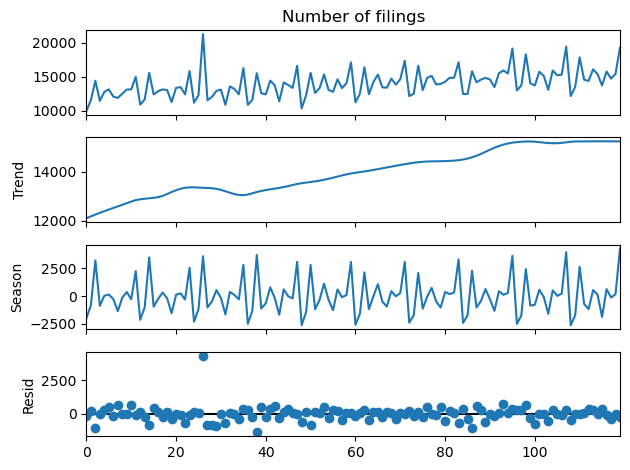

In [5]:
# Initialise STL
stl = STL(unique_ts['Number of filings'], period=12) 

# Perform decomposition
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Plot the decomposition
result.plot()
plt.show()

By looking at the plots of the three different components, it is clear that there is an increasing trend in the series up to the last part, when it starts a decreasing phase. It is also evident the seasonality. The last plot tells us that the residuals, except for an outlier, fall very close to 0 value, meaning that they are not a function of time and follow a Standard Normal distribution. This is good news, since time series with homoskedastic are easier to handle. Some traditional forecasting models, such as ARIMA models, have the homoskedasticity of the residuals in their assumptions, making them not well-suited for data with heteroskedastic residuals.

Another usual step performed in order to assess if the data presents patterns is to plot the **Autocorrelation Function**. This mathematical function computes the correlation between the observations of the time series. In case of trends, the autocorrelation function would show high (in absolute value) values of correlation with previous (adjacent) observations. In case of seasonality, the correlation values will be high in correspondence with the values at the specific lag of the seasonality.

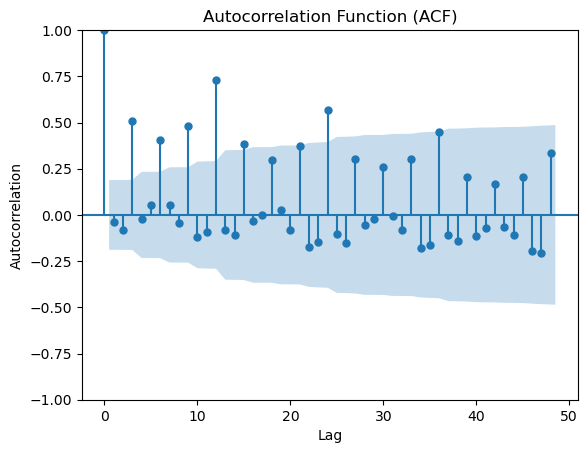

In [6]:
# Split in train and test set
train = unique_ts['Number of filings'][:-12]
test = unique_ts['Number of filings'][-12:]

# Plot ACF
plot_acf(train, lags=48)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (ACF)")
plt.show()

The plot shows high correlations of the last value of the time series with the observations just before it, suggesting a trend in the data. Moreover, there is a strong correlation at lags 12 and 24, meaning a yearly seasonality.

We have performed the analysis on the data retrieved from PATSTAT. However, this can be replicated with ease on other datasets. Now we switch to EPAB to have one more year in the dataset but we do not repeat this preliminary analysis.

### EP full-text data

Now we pass to EP full-text so that we can have access to complete data up to 2022. First we initialise the client.

In [7]:
# Importing the EP full-text client
from epo.tipdata.epab import EPABClient

# Creating an instance of the EP full-text client with the TEST database
epab = EPABClient(env='PROD')
# Getting the name of the database
print(epab.full_table_name)

p-epo-tip-prj-3a1f.p_epo_tip_euwe4_bqd_epab.publications


We can display all the fields of all the tables in the dataset. This way, we can easily explore the structure of EP full-text data.

In [8]:
epab.fields()

WidDatabaseFields(header='', input_data={'': [{'name': 'epab_doc_id', 'type': 'STRING', 'mode': 'REQUIRED', 'd…

Now we are ready to build the query. We want to extract the year and the month from `application.filing_date` and to count the distinct application numbers, grouping by year and by month. The only filter, in the WHERE clause, is that the year must be greater than 2011 and smaller than 2023. The results are order first by year and then by month.

In [9]:
import os

import pandas as pd

home = os.environ["HOME"]
csv_path = f"{home}/epfulltext_unique_ts.csv"

# Build query statements
selection = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, EXTRACT(MONTH FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS month, COUNT(DISTINCT application.number) AS Number_of_filings"
what_to_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 2011 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023"
group_statement = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)), EXTRACT(MONTH FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year, month"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}` "
    f"WHERE {what_to_filter} "
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
result = epab.sql_query(query)
# Covert to dataframe
result_df = pd.DataFrame(result)
# Join year and month in the same column
result_df['year_month'] = [f"{year}-{month}" for year, month in zip(result_df['year'], result_df['month'])]
# Delete the year and month columns from the dataframe
result_df = result_df.drop(['year', 'month'], axis=1)
# Save to CSV file
result_df.to_csv(csv_path, index=False)
result_df

,Number_of_filings,year_month
0,9538,2012-1
1,11066,2012-2
2,13858,2012-3
3,10981,2012-4
4,12229,2012-5
...,...,...
127,14061,2022-8
128,15264,2022-9
129,14151,2022-10
130,15105,2022-11


Again, we display the the time series.

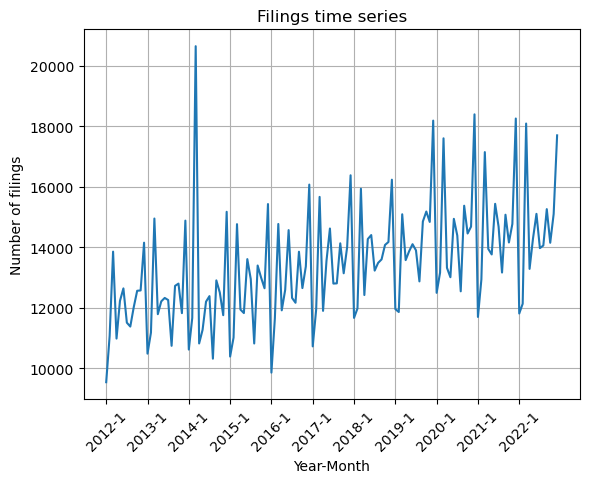

In [10]:
fig, ax = plt.subplots()

# Define the amounts to be displayed retriving them from the dataframe created in the previous box
year_month = result_df['year_month']
filings = result_df['Number_of_filings']
dates_subset = year_month[::12]

ax.plot(year_month, filings)

plt.xticks(dates_subset, rotation=45)

# Set axes labels and title of the plot
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of filings')
ax.set_title('Filings time series')

plt.grid(True)

plt.show()

## Time series divided by applicant country

The split is done according to the 5 areas/countries with the highest number of filings: US, EPO member states, China, Japan, and South Korea.

### PATSTAT data

The PERSON_CTRY_CODE attribute in PATSTAT is not complete, hence it is not possible to separate the data by applicant country via this database. However, we do use PATSTAT to retrieve the different codes and names saved in PATSTAT for EPO members countries. This is because in table TLS801 we find the boolean attribute `epo_member`. It enhances to easily retrieve the countries that are part of the EPO members group. Then, we can go back to EPAB and filter the applicant country according to the list of EPO members provided by table TLS801 in PATSTAT.

In [11]:
from epo.tipdata.patstat import PatstatClient

# Initialise the PATSTAT client
patstat = PatstatClient(env='PROD')

# Access ORM
db = patstat.orm()

# Importing the as models
from epo.tipdata.patstat.database.models import TLS801_COUNTRY

In [12]:
epo_members = db.query(
    TLS801_COUNTRY.ctry_code,
    TLS801_COUNTRY.iso_alpha3,
    TLS801_COUNTRY.st3_name
).filter(
    TLS801_COUNTRY.epo_member == 'Y'  # Boolean filter to retrieve EPO members only
)

epo_members_df = patstat.df(epo_members)
epo_members_df

,ctry_code,iso_alpha3,st3_name
0,MT,MLT,Malta
1,MC,MCO,Monaco
2,AL,ALB,Albania
3,MK,MKD,North Macedonia
4,SM,SMR,San Marino
5,RS,SRB,Serbia
6,LI,LIE,Liechtenstein
7,ME,MNE,Montenegro
8,BG,BGR,Bulgaria
9,RO,ROU,Romania


### EP full-text data

From EP full-text we retrieve the data similarly to how we did for the univariate time series. Since our goal is to include the GDP (Gross Domestic Product) in the features set during training, and GDP data is available only per year, we extract the year only, grouping and ordering by it. We need to enlarge the dataset because of the size reduction resulting from the removing of the months. Therefor, in order to have enough data to train the models we consider applications starting from 1990.

For sake of completeness, in the previous section we showed the names of the countries and both of the codes stored in the table. However, since the attribute `applicant.country` in EP full-text is the `ctry_code` format found in table TLS801 in PATSTAT, we create a list containing EPO members saving only the `ctry_code` attribute from table TLS801.

In [13]:
import pandas as pd

epo_states_list = []

for country_code in epo_members_df['ctry_code']:
    epo_states_list.append(country_code)

# Convert Python list to SQL-friendly format
epo_states_sql = ", ".join(f"'{state}'" for state in epo_states_list)

# Build query statements
selection = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, COUNT(DISTINCT application.number) AS Number_of_filings"
years_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 1989 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023"
group_statement = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}`, UNNEST(applicant) AS applicant "
    f"WHERE {years_filter} AND applicant.country IN ({epo_states_sql})"
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
filings_per_epo_country = epab.sql_query(query)
# Covert to dataframe
filings_per_epo_country_df = pd.DataFrame(filings_per_epo_country)
filings_per_epo_country_df

,country,year,Number_of_filings
0,AT,1990,727
1,LU,1990,59
2,IE,1990,76
3,TR,1990,4
4,GB,1990,4644
...,...,...,...
1176,FI,2022,2181
1177,AL,2022,6
1178,CZ,2022,218
1179,AT,2022,2021


Now we have to sum the number of filings for each year, in order to have a unique time series for the entity EPO.

In [14]:
epo_filings_per_year = []

for year in filings_per_epo_country_df['year'].unique():
    curr_year = filings_per_epo_country_df[filings_per_epo_country_df['year'] == year]
    epo_filings_per_year.append(curr_year['Number_of_filings'].sum())

filings_from_epo_countries = pd.DataFrame({'Year': filings_per_epo_country_df['year'].unique(), 'Number_of_filings': epo_filings_per_year})
filings_from_epo_countries

,Year,Number_of_filings
0,1990,36548
1,1991,32921
2,1992,35079
3,1993,36210
4,1994,38053
5,1995,41673
6,1996,44864
7,1997,50826
8,1998,48827
9,1999,49932


The same must be done for the other countries.

In [15]:
# Build query statements
selection = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, COUNT(DISTINCT application.number) AS Number_of_filings"
what_to_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 1989 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023 AND applicant.country = 'US'"
group_statement = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}`, UNNEST(applicant) AS applicant "
    f"WHERE {what_to_filter} "
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
usa_filings = epab.sql_query(query)
# Covert to dataframe
usa_filings = pd.DataFrame(usa_filings)

In [16]:
# Build query statements
selection = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, COUNT(DISTINCT application.number) AS Number_of_filings"
what_to_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 1989 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023 AND applicant.country = 'CN'"
group_statement = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}`, UNNEST(applicant) AS applicant "
    f"WHERE {what_to_filter} "
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
china_filings = epab.sql_query(query)
# Covert to dataframe
china_filings = pd.DataFrame(china_filings)

In [17]:
# Build query statements
selection = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, COUNT(DISTINCT application.number) AS Number_of_filings"
what_to_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 1989 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023 AND applicant.country = 'JP'"
group_statement = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}`, UNNEST(applicant) AS applicant "
    f"WHERE {what_to_filter} "
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
jp_filings = epab.sql_query(query)
# Covert to dataframe
jp_filings = pd.DataFrame(jp_filings)

In [18]:
# Build query statements
selection = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) AS year, COUNT(DISTINCT application.number) AS Number_of_filings"
what_to_filter = "EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) > 1989 AND EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date)) < 2023 AND applicant.country = 'KR'"
group_statement = "applicant.country, EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', application.filing_date))"
order_condition = "year"

# Build query
query = (
    f"SELECT {selection} "
    f"FROM `{epab.full_table_name}`, UNNEST(applicant) AS applicant "
    f"WHERE {what_to_filter} "
    f"GROUP BY {group_statement} "
    f"ORDER BY {order_condition};"
)

# Run query and get the result
kor_filings = epab.sql_query(query)
# Covert to dataframe
kor_filings = pd.DataFrame(kor_filings)

### GDP data

It is time to load the GDP data, that has been retrieved from [Our World In Data website](https://ourworldindata.org/grapher/national-gdp-wb?tab=table). Direct source: World Bank.

We start by selecting the EPO members.

In [19]:
gdp = pd.read_csv('GDP.csv')

gdp_epo_countries = gdp[gdp['Code'].isin(epo_members_df['iso_alpha3'])]
gdp_epo_countries

,Entity,Code,Year,ny_gdp_mktp_pp_kd
20,Albania,ALB,1990,15864306644
21,Albania,ALB,1991,11421961025
22,Albania,ALB,1992,10601052017
23,Albania,ALB,1993,11614450223
24,Albania,ALB,1994,12578782531
...,...,...,...,...
6260,United Kingdom,GBR,2018,3084593387251
6261,United Kingdom,GBR,2019,3135230411487
6262,United Kingdom,GBR,2020,2810423650417
6263,United Kingdom,GBR,2021,3054225207300


Now we sum the number of filings in all the selected countries for each year, obtaining the GDP time series for the entity EPO.

In [20]:
yearly_gdp = []

for year in gdp_epo_countries['Year'].unique():
    gdp_per_year = gdp_epo_countries[gdp_epo_countries['Year'] == year]
    yearly_gdp.append(gdp_per_year['ny_gdp_mktp_pp_kd'].sum())

epo_gdp = pd.DataFrame({'Code': ['EPO']*len(yearly_gdp), 'Year': gdp_epo_countries['Year'].unique(), 'ny_gdp_mktp_pp_kd': yearly_gdp, 'Number_of_filings': filings_from_epo_countries['Number_of_filings'].values})

We do similarly for USA, China, Japan, and Souht Korea. It is worth to highlight a technicality of Python: since we generate the dataframes containing the data about the GDP of the different countries as a slice of the general GDP dataframe, when we try to create a new column of the slice we have to work on a copy of it. This avoid ambiguity and warning messages.

In [21]:
gdp_usa = gdp[gdp['Code'] == 'USA']
gdp_usa = gdp_usa.copy()
gdp_usa['Number_of_filings'] = usa_filings['Number_of_filings'].values
gdp_usa = gdp_usa.drop(['Entity'], axis=1)

In [22]:
gdp_china = gdp[gdp['Code'] == 'CHN']
gdp_china = gdp_china.copy()
gdp_china['Number_of_filings'] = china_filings['Number_of_filings'].values
gdp_china = gdp_china.drop(['Entity'], axis=1)

In [23]:
gdp_jp = gdp[gdp['Code'] == 'JPN']
gdp_jp = gdp_jp.copy()
gdp_jp['Number_of_filings'] = jp_filings['Number_of_filings'].values
gdp_jp = gdp_jp.drop(['Entity'], axis=1)

In [24]:
gdp_kor = gdp[gdp['Entity'] == 'South Korea']
gdp_kor = gdp_kor.copy()
gdp_kor['Number_of_filings'] = kor_filings['Number_of_filings'].values
gdp_kor = gdp_kor.drop(['Entity'], axis=1)

It is better to merge everything in a single dataframe, hence we concatenate the yearly filings dataframe and the GDP dataframe, for each country.

In [25]:
import os

home = os.environ["HOME"]
csv_path = f"{home}/filings_with_ex_var.csv"

filings_with_ex_var_df = pd.concat([epo_gdp, gdp_usa, gdp_china, gdp_jp, gdp_kor], axis=0, ignore_index=True)
filings_with_ex_var_df.to_csv(csv_path)
filings_with_ex_var_df

,Code,Year,ny_gdp_mktp_pp_kd,Number_of_filings
0,EPO,1990,14617029057568,36548
1,EPO,1991,14932205140758,32921
2,EPO,1992,15157873163510,35079
3,EPO,1993,15199700564113,36210
4,EPO,1994,15568938791637,38053
...,...,...,...,...
160,KOR,2018,2164812897274,7945
161,KOR,2019,2213390819401,9015
162,KOR,2020,2197688684965,9753
163,KOR,2021,2292293355002,10140


We can plot and compare the time series of each country, both for filings and GDP.

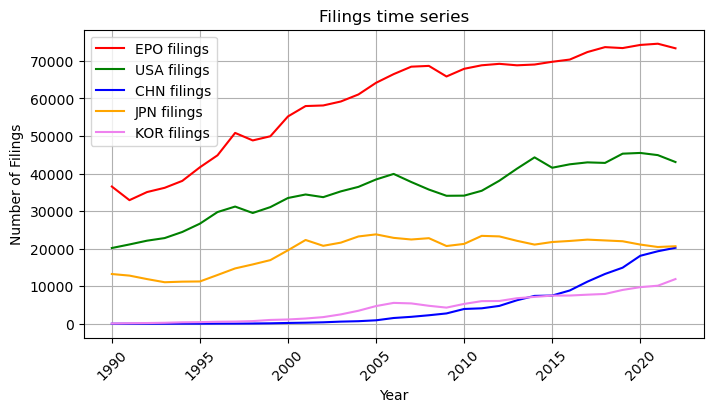

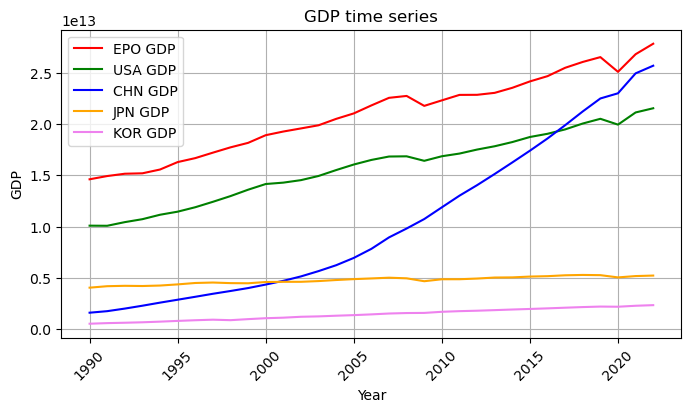

In [26]:
import matplotlib.pyplot as plt

colours = ['red', 'green', 'blue', 'orange', 'violet']

plt.figure(figsize=(8, 4))
for color, country in zip(colours, filings_with_ex_var_df['Code'].unique()):
    country_data = filings_with_ex_var_df[filings_with_ex_var_df['Code'] == country]
    
    # Define the amounts to be displayed retriving them from the dataframe created in the previous box
    years = country_data['Year']
    country_filings = country_data['Number_of_filings']
    
    plt.plot(years, country_filings, color=color, label=f'{country} filings')
    
plt.xticks(rotation=45)

# Set axes labels and title of the plot
plt.xlabel('Year')
plt.ylabel('Number of Filings')
plt.title('Filings time series')
plt.legend()
plt.grid(True)
    
plt.show()

plt.figure(figsize=(8, 4))
for color, country in zip(colours, filings_with_ex_var_df['Code'].unique()):
    country_data = filings_with_ex_var_df[filings_with_ex_var_df['Code'] == country]
    
    # Define the amounts to be displayed retriving them from the dataframe created in the previous box
    years = country_data['Year']
    country_gdp = country_data['ny_gdp_mktp_pp_kd']
    
    plt.plot(years, country_gdp, color=color, label=f'{country} GDP')
    
plt.xticks(rotation=45)

# Set axes labels and title of the plot
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP time series')
plt.legend()
plt.grid(True)
    
plt.show()

By looking at the plots, we can already see a correlation between GDP and number of filings. A rise in one of the two amounts correspond to a rise in the other. Let's investigate this a bit more in detail.

# Correlation between number of filings and GDP

Exogenous variables, like GDP in this case, may be helpful in improving the accuracy of the forecast if they are correlated to the target variable. We can simply understand their efficacy by including the exogenous factors in the model and see if this improves the results. However, we can perform a preliminary check by displaying the **scatterplot**. A scatterplot, also called a scatter plot, scatter graph, scatter chart, scattergram, or scatter diagram, is a type of plot or mathematical diagram that displays values for typically two variables for a set of data. Specifically in this case, what we get is a set of for graphics:
- In the top-right there are the dots representing the values of GDP observed for the set of number of filings;
- In the bottom-left there is the reverse, i.e. the number of filings corresponding to certain values of GDP;
- Choosing 'kde' (that stands for 'Kernel Density Estimation') for the 'diag_kind' parameter of the `pairplot` method, we obtain, in the top-left, an estimation of the probability to find a certain value of GDP picking randomly from the dataset;
- For the same token, in the bottom-right there is an enstimation of the density of the values of number of filings observed in the sample at hand.

For the scope of this notebook, what the kernel density estimation represents in this specific context is succinctly explained above. For the ones interested in the technical details, the [Wikipedia page](https://en.wikipedia.org/wiki/Kernel_density_estimation) is a good starting point.

Let's start by importing the seaborn library to build the scatterplot.

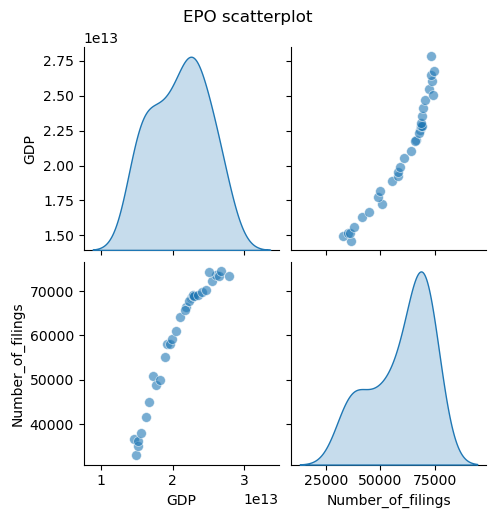

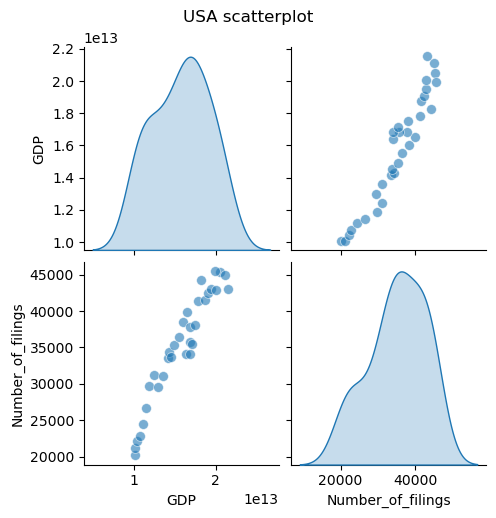

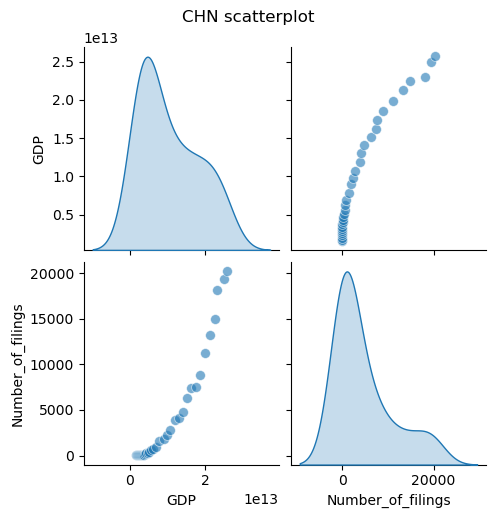

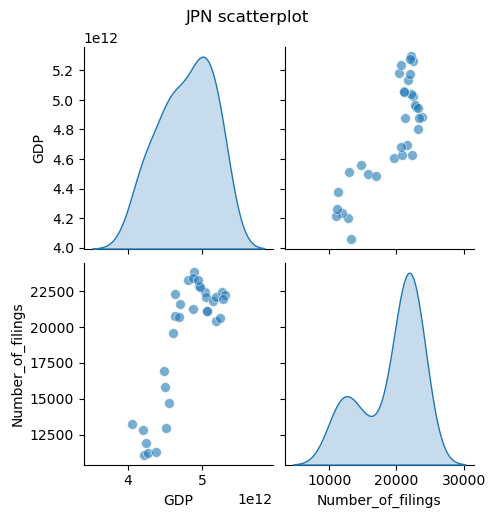

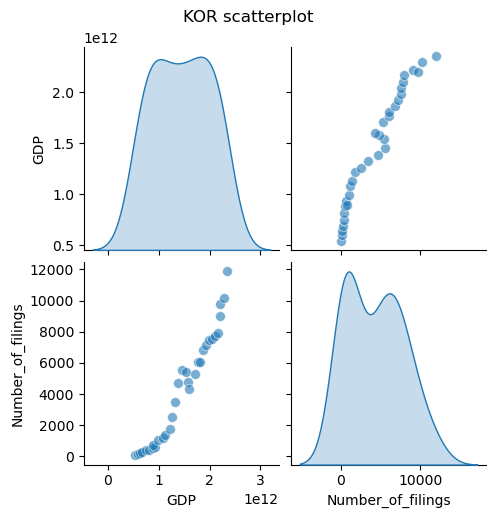

In [27]:
import seaborn as sns

for country in filings_with_ex_var_df['Code'].unique():
    country_data = filings_with_ex_var_df[filings_with_ex_var_df['Code'] == country]
    # Rename GDP column for sake of clarity in the visualisation
    country_data = country_data.rename(columns={'ny_gdp_mktp_pp_kd': 'GDP'})
    # Create the correlogram
    sns.pairplot(country_data[['GDP', 'Number_of_filings']], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50})
    # Display the plot
    plt.suptitle(f"{country} scatterplot", y=1.02)  
    plt.show()

The plots clearly show that the number of filings and GDP are positively correlated: at lower values of the one correspond lower values of the other, and higher values of the one comes along with higher values of the other.